# Lab 1 — Python y pandas: primer contacto con datos reales
### TC4036 · Ciencia de Datos para Políticas Públicas

---

> **Sobre el uso de IA:** Puedes usar ChatGPT, Copilot o Claude para ayudarte con el código. Pero asegúrate de entender cada línea — en clase podría pedirte que la expliques. El objetivo es aprender a pensar con datos.

> **Este lab es colaborativo.** Si algo no funciona, habla con quien tengas al lado o llama al instructor. Muchos bugs se resuelven solos cuando los explicas en voz alta.

---

**Al terminar este lab habrás:**
- Escrito tus primeras líneas de Python
- Cargado un dataset real con datos de ~80 países
- Leído una tabla de datos y entendido lo que dice
- Hecho tu primera gráfica
- Cambiado el código para explorar un país o región de tu elección

**Lo que NO cubrimos hoy** (viene en semanas posteriores): limpieza de datos, merge, estadística, machine learning. Hoy solo tocamos la superficie — suficiente para tener una idea de a dónde vamos.

---
## Parte 0 · Setup

Ejecuta la celda de abajo. Si ves `✓ Todo listo`, puedes continuar. Si ves un error, levanta la mano.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'sans-serif'

print('✓ Todo listo. pandas', pd.__version__)

✓ Todo listo. pandas 2.2.3


---
## Parte 1 · Python en 10 minutos

Solo veremos lo estrictamente necesario para el resto del lab. No necesitas memorizar esto — lo irás reconociendo con la práctica.

In [2]:
# Una variable guarda un valor con un nombre
pais       = "México"
poblacion  = 129_000_000   # el guión bajo es solo para legibilidad
gdp        = 8_329.53

# f-string: la forma más cómoda de combinar texto y variables
print(f"{pais} tiene {poblacion:,} habitantes y un GDP per cápita de ${gdp:,.0f}")

México tiene 129,000,000 habitantes y un GDP per cápita de $8,330


In [3]:
# Una lista guarda varios valores en orden
paises_latam = ["México", "Brasil", "Colombia", "Argentina", "Chile", "Peru"]

# Un loop repite algo para cada elemento de la lista
for p in paises_latam:
    print(" -", p)

my_numbers= [23.4, 764.8, 4253.3, 4.3, 81.1]
for n in range(0,len(my_numbers)):
    print(f"Numero {n} = {my_numbers[n]}")

 - México
 - Brasil
 - Colombia
 - Argentina
 - Chile
 - Peru
Numero 0 = 23.4
Numero 1 = 764.8
Numero 2 = 4253.3
Numero 3 = 4.3
Numero 4 = 81.1


Eso es suficiente Python por ahora. Hay más conceptos (diccionarios, funciones, condicionales) que iremos introduciendo cuando los necesitemos en semanas posteriores.

---
## Parte 2 · ¿Qué es un DataFrame?

Un **DataFrame** es la estructura de datos central de pandas. Piensa en él como una hoja de cálculo de Excel, pero:
- puedes manipularlo con código (reproducible, automatizable)
- puede tener millones de filas sin problema
- cada paso queda registrado en el notebook

La estructura es simple: **filas = observaciones**, **columnas = variables**.

In [4]:
# Crear un DataFrame pequeño a mano para ver cómo funciona
# Agrega una variable al data frame
datos = {
    "pais":       ["México", "Brasil", "Colombia", "Argentina", "Peru"],
    "gdp_percap": [8_329,    6_796,    5_791,       8_442, 5],
    "vida":       [75.0,     75.8,     77.2,        76.6, 70.],
    "comida":     ["tacos", "pan de quesio", "arepas", "choripan", "causa"]
}

tabla = pd.DataFrame(datos)
tabla   # escribir el nombre de la variable al final muestra la tabla

,pais,gdp_percap,vida,comida
0,México,8329,75.0,tacos
1,Brasil,6796,75.8,pan de quesio
2,Colombia,5791,77.2,arepas
3,Argentina,8442,76.6,choripan
4,Peru,5,70.0,causa


In [5]:
# Acceder a una columna — como un diccionario con el nombre entre corchetes
print("GDP per cápita de los cuatro países:")
print(tabla["gdp_percap"])

print(f"\nPromedio: ${tabla['gdp_percap'].mean():,.0f}")
print(f"Mayor:    ${tabla['gdp_percap'].max():,.0f}")

GDP per cápita de los cuatro países:
0    8329
1    6796
2    5791
3    8442
4       5
Name: gdp_percap, dtype: int64

Promedio: $5,873
Mayor:    $8,442


---
## Parte 3 · Cargar datos reales

Ahora vamos a cargar un dataset real: indicadores de desarrollo del **Banco Mundial** para ~80 países en el año 2020. Incluye GDP per cápita, esperanza de vida, población, región y grupo de ingreso.

In [6]:
import io

# Datos del Banco Mundial, año 2020
# Fuente: World Development Indicators
_raw = """
pais,codigo,region,grupo_ingreso,gdp_percap,esp_vida,poblacion
Afghanistan,AFG,South Asia,Low income,516,62.6,38928341
Albania,ALB,Europe & Central Asia,Upper middle income,5352,78.6,2837743
Algeria,DZA,Middle East & North Africa,Lower middle income,3328,76.9,43851043
Angola,AGO,Sub-Saharan Africa,Lower middle income,1934,61.2,32866268
Argentina,ARG,Latin America & Caribbean,Upper middle income,8442,76.7,45195774
Armenia,ARM,Europe & Central Asia,Upper middle income,4226,74.9,2963234
Australia,AUS,East Asia & Pacific,High income,51812,83.4,25499884
Austria,AUT,Europe & Central Asia,High income,48291,81.4,9006398
Bangladesh,BGD,South Asia,Lower middle income,1961,72.6,164689383
Belgium,BEL,Europe & Central Asia,High income,44530,81.9,11555997
Bolivia,BOL,Latin America & Caribbean,Lower middle income,3104,63.9,11673029
Brazil,BRA,Latin America & Caribbean,Upper middle income,6796,75.9,212559409
Bulgaria,BGR,Europe & Central Asia,Upper middle income,9961,75.1,6951482
Burkina Faso,BFA,Sub-Saharan Africa,Low income,826,61.6,21510181
Cambodia,KHM,East Asia & Pacific,Lower middle income,1512,70.0,16718971
Canada,CAN,North America,High income,43242,83.0,38005238
Chile,CHL,Latin America & Caribbean,High income,13231,80.2,19116209
China,CHN,East Asia & Pacific,Upper middle income,10434,77.1,1411100000
Colombia,COL,Latin America & Caribbean,Upper middle income,5791,77.3,50882884
Costa Rica,CRI,Latin America & Caribbean,Upper middle income,11834,80.3,5094114
Czech Republic,CZE,Europe & Central Asia,High income,23377,79.1,10698896
Denmark,DNK,Europe & Central Asia,High income,60948,81.6,5831404
Dominican Republic,DOM,Latin America & Caribbean,Upper middle income,7435,74.1,10847904
DR Congo,COD,Sub-Saharan Africa,Low income,545,60.7,89561404
Ecuador,ECU,Latin America & Caribbean,Upper middle income,5584,77.6,17643060
Egypt,EGY,Middle East & North Africa,Lower middle income,3520,72.0,102334403
El Salvador,SLV,Latin America & Caribbean,Lower middle income,3943,73.6,6486201
Ethiopia,ETH,Sub-Saharan Africa,Low income,855,67.8,114963583
Finland,FIN,Europe & Central Asia,High income,48686,82.0,5530719
France,FRA,Europe & Central Asia,High income,40493,82.7,67391582
Germany,DEU,Europe & Central Asia,High income,46468,81.3,83240525
Ghana,GHA,Sub-Saharan Africa,Lower middle income,2202,64.1,31072945
Greece,GRC,Europe & Central Asia,High income,18111,82.2,10715000
Guatemala,GTM,Latin America & Caribbean,Upper middle income,4048,74.3,16858333
Haiti,HTI,Latin America & Caribbean,Low income,1149,64.1,11402533
Honduras,HND,Latin America & Caribbean,Lower middle income,2405,75.3,9904608
Hungary,HUN,Europe & Central Asia,High income,16487,75.6,9749763
India,IND,South Asia,Lower middle income,1900,69.7,1380004385
Indonesia,IDN,East Asia & Pacific,Upper middle income,3869,71.7,273523621
Ireland,IRL,Europe & Central Asia,High income,94392,82.3,4994724
Italy,ITA,Europe & Central Asia,High income,33227,83.5,60461826
Japan,JPN,East Asia & Pacific,High income,40146,84.6,125836021
Kenya,KEN,Sub-Saharan Africa,Lower middle income,1838,66.7,53771300
Malaysia,MYS,East Asia & Pacific,Upper middle income,10402,76.5,32365998
Mexico,MEX,Latin America & Caribbean,Upper middle income,8329,75.1,128932753
Morocco,MAR,Middle East & North Africa,Lower middle income,3204,76.7,36910558
Mozambique,MOZ,Sub-Saharan Africa,Low income,479,60.9,31255435
Netherlands,NLD,Europe & Central Asia,High income,52668,82.3,17441139
New Zealand,NZL,East Asia & Pacific,High income,42084,82.3,5084300
Nicaragua,NIC,Latin America & Caribbean,Lower middle income,1937,74.5,6624554
Nigeria,NGA,Sub-Saharan Africa,Lower middle income,2097,54.7,206139587
Norway,NOR,Europe & Central Asia,High income,67176,82.9,5379475
Pakistan,PAK,South Asia,Lower middle income,1193,67.3,220892331
Panama,PAN,Latin America & Caribbean,High income,12516,78.5,4351267
Paraguay,PRY,Latin America & Caribbean,Upper middle income,5316,74.3,7132538
Peru,PER,Latin America & Caribbean,Upper middle income,6035,76.7,32971846
Philippines,PHL,East Asia & Pacific,Lower middle income,3298,72.7,109581085
Poland,POL,Europe & Central Asia,High income,15694,78.5,37950802
Portugal,PRT,Europe & Central Asia,High income,23060,81.9,10305564
Romania,ROU,Europe & Central Asia,High income,12896,76.1,19329265
Russia,RUS,Europe & Central Asia,Upper middle income,10126,71.3,144104080
Rwanda,RWA,Sub-Saharan Africa,Low income,780,69.0,12952218
Saudi Arabia,SAU,Middle East & North Africa,High income,22321,75.1,34813867
Senegal,SEN,Sub-Saharan Africa,Lower middle income,1399,67.9,16743930
South Africa,ZAF,Sub-Saharan Africa,Upper middle income,5090,64.1,59308690
South Korea,KOR,East Asia & Pacific,High income,31497,83.5,51780579
Spain,ESP,Europe & Central Asia,High income,29564,83.6,47351567
Sweden,SWE,Europe & Central Asia,High income,52274,82.8,10379295
Switzerland,CHE,Europe & Central Asia,High income,86601,83.9,8654622
Tanzania,TZA,Sub-Saharan Africa,Lower middle income,1084,65.5,59734213
Thailand,THA,East Asia & Pacific,Upper middle income,7066,77.5,71601103
Turkey,TUR,Europe & Central Asia,Upper middle income,9041,77.7,84339067
Uganda,UGA,Sub-Saharan Africa,Low income,780,63.4,45741000
Ukraine,UKR,Europe & Central Asia,Lower middle income,3726,72.1,43733759
United Kingdom,GBR,Europe & Central Asia,High income,40284,80.9,67215293
United States,USA,North America,High income,63543,78.5,331002647
Uruguay,URY,Latin America & Caribbean,High income,15437,77.9,3473727
Venezuela,VEN,Latin America & Caribbean,Upper middle income,3374,72.1,28435940
Vietnam,VNM,East Asia & Pacific,Lower middle income,2786,73.6,97338583
Zambia,ZMB,Sub-Saharan Africa,Low income,1027,63.9,18383956
Zimbabwe,ZWE,Sub-Saharan Africa,Low income,1463,61.5,14862924
"""

df = pd.read_csv(io.StringIO(_raw.strip()))
print(f"✓ Dataset cargado: {len(df)} países, {len(df.columns)} columnas")

✓ Dataset cargado: 81 países, 7 columnas


---
## Parte 4 · Explorar — ¿qué tenemos?

Antes de hacer cualquier análisis, siempre hay que entender el dataset.

In [7]:
# .head() muestra las primeras filas
# Empieza siempre aquí — te da una idea inmediata de la estructura
df.head(15)
df.tail(15)

,pais,codigo,region,grupo_ingreso,gdp_percap,esp_vida,poblacion
66,Spain,ESP,Europe & Central Asia,High income,29564,83.6,47351567
67,Sweden,SWE,Europe & Central Asia,High income,52274,82.8,10379295
68,Switzerland,CHE,Europe & Central Asia,High income,86601,83.9,8654622
69,Tanzania,TZA,Sub-Saharan Africa,Lower middle income,1084,65.5,59734213
70,Thailand,THA,East Asia & Pacific,Upper middle income,7066,77.5,71601103
71,Turkey,TUR,Europe & Central Asia,Upper middle income,9041,77.7,84339067
72,Uganda,UGA,Sub-Saharan Africa,Low income,780,63.4,45741000
73,Ukraine,UKR,Europe & Central Asia,Lower middle income,3726,72.1,43733759
74,United Kingdom,GBR,Europe & Central Asia,High income,40284,80.9,67215293
75,United States,USA,North America,High income,63543,78.5,331002647


**💬 Pausa:** Sin escribir nada de código — solo mirando la tabla — ¿qué notas? ¿Hay algo que te llame la atención o que no te esperabas?

In [8]:
filtro = df["esp_vida"]<80
df_filtered = df[filtro]

display(df_filtered)

print("Data frame original\n")
df


,pais,codigo,region,grupo_ingreso,gdp_percap,esp_vida,poblacion
0,Afghanistan,AFG,South Asia,Low income,516,62.6,38928341
1,Albania,ALB,Europe & Central Asia,Upper middle income,5352,78.6,2837743
2,Algeria,DZA,Middle East & North Africa,Lower middle income,3328,76.9,43851043
3,Angola,AGO,Sub-Saharan Africa,Lower middle income,1934,61.2,32866268
4,Argentina,ARG,Latin America & Caribbean,Upper middle income,8442,76.7,45195774
5,Armenia,ARM,Europe & Central Asia,Upper middle income,4226,74.9,2963234
8,Bangladesh,BGD,South Asia,Lower middle income,1961,72.6,164689383
10,Bolivia,BOL,Latin America & Caribbean,Lower middle income,3104,63.9,11673029
11,Brazil,BRA,Latin America & Caribbean,Upper middle income,6796,75.9,212559409
12,Bulgaria,BGR,Europe & Central Asia,Upper middle income,9961,75.1,6951482


Data frame original



,pais,codigo,region,grupo_ingreso,gdp_percap,esp_vida,poblacion
0,Afghanistan,AFG,South Asia,Low income,516,62.6,38928341
1,Albania,ALB,Europe & Central Asia,Upper middle income,5352,78.6,2837743
2,Algeria,DZA,Middle East & North Africa,Lower middle income,3328,76.9,43851043
3,Angola,AGO,Sub-Saharan Africa,Lower middle income,1934,61.2,32866268
4,Argentina,ARG,Latin America & Caribbean,Upper middle income,8442,76.7,45195774
...,...,...,...,...,...,...,...
76,Uruguay,URY,Latin America & Caribbean,High income,15437,77.9,3473727
77,Venezuela,VEN,Latin America & Caribbean,Upper middle income,3374,72.1,28435940
78,Vietnam,VNM,East Asia & Pacific,Lower middle income,2786,73.6,97338583
79,Zambia,ZMB,Sub-Saharan Africa,Low income,1027,63.9,18383956


In [9]:
# .describe() da estadísticas resumidas de todas las columnas numéricas
# Lee: count (cuántos), mean (promedio), std (dispersión), min, 25%, 50%, 75%, max
df.describe().round(1)

,gdp_percap,esp_vida,poblacion
count,81.0,81.0,8.100000e+01
mean,17239.5,74.6,8.442506e+07
std,21678.9,7.2,2.193371e+08
min,479.0,54.7,2.837743e+06
25%,2202.0,70.0,1.069890e+07
50%,6796.0,75.9,3.125544e+07
75%,23377.0,80.9,6.721529e+07
max,94392.0,84.6,1.411100e+09


**💬 Pausa:** Mira el GDP per cápita.
- El promedio (`mean`) es ~$16,000. La mediana (`50%`) es ~$7,000. ¿Por qué son tan diferentes?
- El mínimo es ~$479 y el máximo ~$94,000. ¿Qué te dice eso sobre la desigualdad global?

In [10]:
# ¿Cuántos países hay de cada región?
df['region'].value_counts()
# df['grupo_ingreso'].unique()

region
Europe & Central Asia         26
Latin America & Caribbean     19
Sub-Saharan Africa            15
East Asia & Pacific           11
South Asia                     4
Middle East & North Africa     4
North America                  2
Name: count, dtype: int64

---
## Parte 5 · Una pregunta, respondida con código

Pregunta concreta de política: **¿Cómo se compara México con el promedio de América Latina?**

Primero filtramos solo los países de LatAm.

In [11]:
# Filtrar: df[condición] — se queda con las filas donde la condición es verdadera
latam = df[df['region'] == 'Latin America & Caribbean'].copy()

print(f"Países de LatAm en el dataset: {len(latam)}")
print(latam[['pais', 'gdp_percap', 'esp_vida']].to_string(index=False))
latam

Países de LatAm en el dataset: 19
              pais  gdp_percap  esp_vida
         Argentina        8442      76.7
           Bolivia        3104      63.9
            Brazil        6796      75.9
             Chile       13231      80.2
          Colombia        5791      77.3
        Costa Rica       11834      80.3
Dominican Republic        7435      74.1
           Ecuador        5584      77.6
       El Salvador        3943      73.6
         Guatemala        4048      74.3
             Haiti        1149      64.1
          Honduras        2405      75.3
            Mexico        8329      75.1
         Nicaragua        1937      74.5
            Panama       12516      78.5
          Paraguay        5316      74.3
              Peru        6035      76.7
           Uruguay       15437      77.9
         Venezuela        3374      72.1


,pais,codigo,region,grupo_ingreso,gdp_percap,esp_vida,poblacion
4,Argentina,ARG,Latin America & Caribbean,Upper middle income,8442,76.7,45195774
10,Bolivia,BOL,Latin America & Caribbean,Lower middle income,3104,63.9,11673029
11,Brazil,BRA,Latin America & Caribbean,Upper middle income,6796,75.9,212559409
16,Chile,CHL,Latin America & Caribbean,High income,13231,80.2,19116209
18,Colombia,COL,Latin America & Caribbean,Upper middle income,5791,77.3,50882884
19,Costa Rica,CRI,Latin America & Caribbean,Upper middle income,11834,80.3,5094114
22,Dominican Republic,DOM,Latin America & Caribbean,Upper middle income,7435,74.1,10847904
24,Ecuador,ECU,Latin America & Caribbean,Upper middle income,5584,77.6,17643060
26,El Salvador,SLV,Latin America & Caribbean,Lower middle income,3943,73.6,6486201
33,Guatemala,GTM,Latin America & Caribbean,Upper middle income,4048,74.3,16858333


In [12]:
# Estadísticas de LatAm y posición de México
promedio = latam['gdp_percap'].mean()
mediana  = latam['gdp_percap'].median()
gdp_mexico  = latam.loc[latam['pais'] == 'Mexico', 'gdp_percap'].values[0]

print("GDP per cápita en América Latina (2020)")
# print(f"  Promedio regional:  ${promedio}")
print(f"  Promedio regional:  ${promedio:>8,.0f}")
print(f"  Mediana regional:   ${mediana:>8,.0f}")
print(f"  Mexico:             ${gdp_mexico:>8,.0f}")

# Posición de México en el ranking
latam_sorted = latam.sort_values('gdp_percap', ascending=False).reset_index(drop=True)
pos = latam_sorted[latam_sorted['pais'] == 'Mexico'].index[0] + 1
print(f"\nMéxico está en el lugar #{pos} de {len(latam)} países de LatAm por GDP per cápita")

GDP per cápita en América Latina (2020)
  Promedio regional:  $   6,669
  Mediana regional:   $   5,791
  Mexico:             $   8,329

México está en el lugar #6 de 19 países de LatAm por GDP per cápita


---
## Parte 6 · La gráfica

Los números de arriba son útiles pero difíciles de comparar visualmente. Una gráfica de barras lo hace inmediato.

Vamos a hacer un **gráfico de barras horizontal** con el GDP per cápita de todos los países de LatAm, resaltando México.

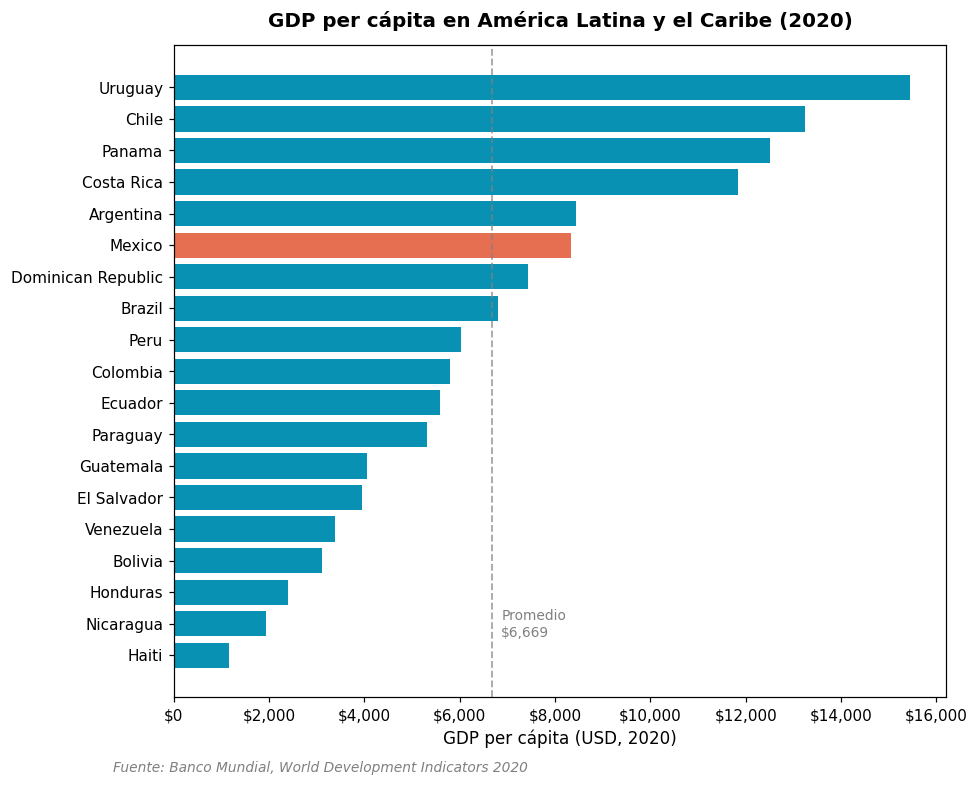

In [13]:
# Ordenar de mayor a menor para que la gráfica sea fácil de leer
latam_ord = latam.sort_values('gdp_percap', ascending=True)  # ascending=True para barh

# Asignar colores: naranja para México, azul para el resto
colores = ['#E76F51' if p == 'Mexico' else '#0891B2' for p in latam_ord['pais']]

# Crear la figura
fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(latam_ord['pais'], latam_ord['gdp_percap'], color=colores)

# Línea del promedio regional
ax.axvline(promedio, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(promedio + 200, 0.5, f'Promedio\n${promedio:,.0f}',
        fontsize=9, color='gray', va='bottom')

# Etiquetas y título
ax.set_xlabel('GDP per cápita (USD, 2020)', fontsize=11)
ax.set_title('GDP per cápita en América Latina y el Caribe (2020)',
             fontsize=13, fontweight='bold', pad=12)

# Formato de números en el eje x
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Fuente
fig.text(0.12, -0.01, 'Fuente: Banco Mundial, World Development Indicators 2020',
         fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.show()

**💬 Pausa:** Mira la gráfica.
- ¿Qué países están muy por encima del promedio? ¿Por qué crees que es?
- ¿Hay algún resultado que te sorprenda?
- ¿Qué le dirías a un funcionario de política económica a partir de esta gráfica?

Nota: una gráfica sola no prueba nada — es el punto de partida de las preguntas, no el final.

---
## Parte 7 · Tu turno — cambia una línea

El único ejercicio de hoy es este: **cambia una región y vuelve a correr las celdas**.

Elige la región que más te interese para tu proyecto o simplemente por curiosidad.

In [14]:
# ── Cambia esta línea ──────────────────────────────────────────────────────────
MI_REGION = 'Sub-Saharan Africa'
# ──────────────────────────────────────────────────────────────────────────────
# Opciones disponibles:
#   'Latin America & Caribbean'
#   'Europe & Central Asia'
#   'East Asia & Pacific'
#   'South Asia'
#   'Middle East & North Africa'
#   'Sub-Saharan Africa'
#   'North America'

mi_df = df[df['region'] == MI_REGION].sort_values('gdp_percap', ascending=True)

if len(mi_df) == 0:
    print("No encontré esa región. Revisa el nombre exacto en las opciones de arriba.")
else:
    print(f"{MI_REGION}: {len(mi_df)} países")
    print(f"GDP promedio: ${mi_df['gdp_percap'].mean():,.0f}")
    print(f"Esperanza de vida promedio: {mi_df['esp_vida'].mean():.1f} años")

Sub-Saharan Africa: 15 países
GDP promedio: $1,493
Esperanza de vida promedio: 63.5 años


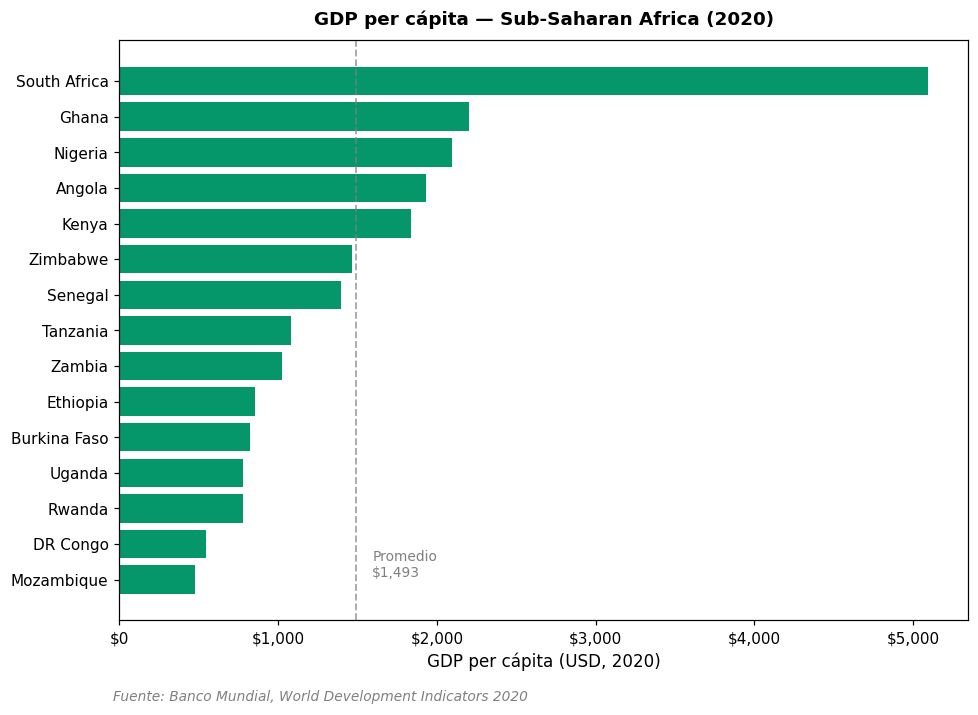

In [15]:
# Gráfica de tu región — exactamente el mismo código que antes
mi_colores = ['#E76F51' if p == 'Mexico' else '#059669' for p in mi_df['pais']]

fig, ax = plt.subplots(figsize=(9, max(4, len(mi_df) * 0.42)))

ax.barh(mi_df['pais'], mi_df['gdp_percap'], color=mi_colores)

prom_region = mi_df['gdp_percap'].mean()
ax.axvline(prom_region, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(prom_region + 100, 0, f'Promedio\n${prom_region:,.0f}',
        fontsize=9, color='gray', va='bottom')

ax.set_xlabel('GDP per cápita (USD, 2020)', fontsize=11)
ax.set_title(f'GDP per cápita — {MI_REGION} (2020)',
             fontsize=12, fontweight='bold', pad=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

fig.text(0.12, -0.02, 'Fuente: Banco Mundial, World Development Indicators 2020',
         fontsize=9, color='gray', style='italic')
plt.tight_layout()
plt.show()

**Escribe aquí 2 observaciones sobre tu región:**

1. *...*
2. *...*

---

## Eso es todo por hoy

Hiciste más de lo que parece:
- Instalaste y configuraste un entorno de análisis de datos
- Cargaste un dataset real con código de dos líneas
- Leíste una tabla y extrajiste conclusiones
- Hiciste una gráfica lista para presentar
- Modificaste el código para explorar tu propia pregunta

**Próxima semana:** Ética y privacidad en datos públicos — qué puedes y no puedes hacer con los datos que acabas de explorar, y por qué los números de GDP per cápita no cuentan toda la historia.

**Para clase:** Trae un artículo o noticia sobre algún caso de sesgo algorítmico o mal uso de datos en política pública. Puede ser en cualquier país y cualquier tema.